
# **Backend y Comunicación**

En la sección de **Backend y Comunicación** se desarrolló toda la infraestructura necesaria para gestionar el flujo de información en un sistema de computación visual en tiempo real. Se implementó un servidor WebSocket capaz de transmitir detecciones, métricas de rendimiento y comandos entre múltiples clientes de manera asíncrona y eficiente, ejecutándose directamente en Google Colab. Además, se incorporaron mecanismos de serialización en JSON y almacenamiento persistente tanto en archivos CSV como en una base de datos SQLite, permitiendo registrar eventos, resultados y estados del sistema para su posterior análisis. También se construyó un dashboard en Python que muestra métricas como FPS, uso de CPU, memoria y GPU, así como el conteo de detecciones procesadas, facilitando una visualización clara del rendimiento del sistema. En conjunto, esta sección integra comunicación en tiempo real, persistencia de datos y monitoreo, sentando la base para sistemas interactivos y escalables de visión por computador.














# 📌 **1. Instalación de dependencias**

En esta primera etapa se instalan todas las bibliotecas necesarias para construir el backend en Colab. Incluye `websockets` para la comunicación en tiempo real, `psutil` para obtener el uso de CPU y RAM, `sqlalchemy` o `sqlite3` para almacenar datos localmente, `pandas` para procesar tablas y `aiofiles` para operaciones asíncronas. También se instala `nest_asyncio`, que permite ejecutar bucles asíncronos dentro del entorno de Jupyter sin bloquear la ejecución. Esta celda prepara el entorno para poder ejecutar un servidor WebSocket y manipular datos en tiempo real dentro de Google Colab.

---

In [1]:
# Cell 1 — instalar dependencias
# Ejecuta esto primero en Colab
!pip install websockets==10.4 apscheduler psutil sqlalchemy pandas aiofiles nest_asyncio

# opcional (si quieres exponer a internet con ngrok)
# !pip install pyngrok


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.9/84.9 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 2.8 MB/s eta 0:00:00
  Created wheel for websockets: filename=websockets-10.4-cp312-cp312-linux_x86_64.whl size=107330 sha256=1e602f448b898fb481d613c60ff6f0a4b4ea11ff8a64ba55017bd2fb4f856e82
  Stored in directory: /root/.cache/pip/wheels/80/cf/6d/5d7e4c920cb41925a178b2d2621889c520d648bab487b1d7fd
Successfully built websockets
  Attempting uninstall: websockets
    Found existing installation: websockets 15.0.1
    Uninstalling websockets-15.0.1:
      Successfully uninstalled websockets-15.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-genai 1.49.0 requires websockets<15.1.0,>=13.0.0, but you have websockets 10.4 which is incompatible.
yfinance 0.2.66 requires websockets>=13

#  **2. Definición del servidor WebSocket, almacenamiento y utilidades**

En esta sección se define el servidor WebSocket que recibirá, procesará y retransmitirá mensajes a todos los clientes conectados. También se configuran los mecanismos de persistencia, creando un archivo CSV y una base de datos SQLite para guardar eventos, detecciones y métricas del sistema. Se implementa un conjunto de utilidades: funciones que registran clientes, serializan mensajes en JSON, guardan información en disco y toman muestras del rendimiento del sistema (CPU, RAM y GPU). Además, se programa un proceso asíncrono que transmite métricas periódicas automáticamente. Todo este bloque constituye el corazón del backend.

---

In [2]:
# Cell 2 — servidor WebSocket, almacenamiento CSV/SQLite, utilidades de métricas
import asyncio
import websockets
import json
import csv
import os
import time
import threading
import sqlite3
from datetime import datetime
from apscheduler.schedulers.background import BackgroundScheduler
import psutil
import subprocess
import pandas as pd

# Config
WS_HOST = "localhost"
WS_PORT = 8765
CSV_PATH = "/content/detections_log.csv"
SQLITE_PATH = "/content/detections.db"

# Asegura CSV con cabecera
if not os.path.exists(CSV_PATH):
    with open(CSV_PATH, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["timestamp","type","payload_json"])  # basic columns

# Inicializa DB sqlite
conn = sqlite3.connect(SQLITE_PATH, check_same_thread=False)
cur = conn.cursor()
cur.execute("""
CREATE TABLE IF NOT EXISTS events (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    timestamp TEXT,
    type TEXT,
    payload TEXT
)
""")
conn.commit()

# In-memory clients set
connected_clients = set()
clients_lock = threading.Lock()

# Broadcast helper
async def broadcast(message: dict):
    """Envia a todos los WebSocket conectados (JSON)"""
    data = json.dumps(message)
    to_remove = []
    async with asyncio.Lock():
        for ws in list(connected_clients):
            try:
                await ws.send(data)
            except Exception:
                to_remove.append(ws)
        for r in to_remove:
            try:
                connected_clients.remove(r)
            except Exception:
                pass

# Persistencia: CSV + SQLite
def persist_event(ev_type: str, payload: dict):
    ts = datetime.utcnow().isoformat() + "Z"
    row = [ts, ev_type, json.dumps(payload)]
    with open(CSV_PATH, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(row)
    cur.execute("INSERT INTO events (timestamp, type, payload) VALUES (?, ?, ?)", (ts, ev_type, json.dumps(payload)))
    conn.commit()

# WebSocket handler
async def ws_handler(websocket, path):
    # register
    with clients_lock:
        connected_clients.add(websocket)
    try:
        async for message in websocket:
            # try parse JSON
            try:
                msg = json.loads(message)
            except Exception:
                # respond with error
                await websocket.send(json.dumps({"type":"error","msg":"invalid json"}))
                continue

            # handle incoming commands from client
            msg_type = msg.get("type","unknown")
            payload = msg.get("payload",{})
            # persist incoming message
            persist_event("incoming_"+msg_type, payload)

            # Example: if client sends 'ping' -> respond pong
            if msg_type == "ping":
                await websocket.send(json.dumps({"type":"pong","payload":{"ts": datetime.utcnow().isoformat()}}))
            elif msg_type == "command":
                # broadcast the command to all
                await broadcast({"type":"command_broadcast","payload": payload})
            elif msg_type == "detection":
                # if a detection arrives, persist and broadcast to others
                persist_event("detection", payload)
                await broadcast({"type":"detection","payload": payload})
            else:
                # generic echo
                await websocket.send(json.dumps({"type":"ack","payload":{"received_type": msg_type}}))
    except websockets.exceptions.ConnectionClosed:
        pass
    finally:
        # unregister
        with clients_lock:
            try:
                connected_clients.remove(websocket)
            except Exception:
                pass

# Function to get CPU, RAM, and GPU info (if Nvidia present)
def sample_system_metrics():
    cpu_percent = psutil.cpu_percent(interval=None)
    ram = psutil.virtual_memory().percent
    gpu_info = None
    # try nvidia-smi if available
    try:
        out = subprocess.check_output(["nvidia-smi","--query-gpu=index,name,memory.used,memory.total,utilization.gpu","--format=csv,nounits,noheader"], stderr=subprocess.DEVNULL)
        lines = out.decode().strip().splitlines()
        gpus = []
        for L in lines:
            parts = [p.strip() for p in L.split(",")]
            gpus.append({
                "index": parts[0],
                "name": parts[1],
                "mem_used_mb": parts[2],
                "mem_total_mb": parts[3],
                "util_gpu_percent": parts[4]
            })
        gpu_info = gpus
    except Exception:
        gpu_info = None
    return {"cpu_percent": cpu_percent, "ram_percent": ram, "gpu": gpu_info, "ts": datetime.utcnow().isoformat()+"Z"}

# Periodic metrics broadcaster
async def broadcast_metrics_periodically(interval_seconds=1.0):
    while True:
        metrics = sample_system_metrics()
        persist_event("system_metrics", metrics)
        await broadcast({"type":"system_metrics","payload": metrics})
        await asyncio.sleep(interval_seconds)

# Run server helper (will be run in background thread)
def start_ws_server_in_thread(host=WS_HOST, port=WS_PORT):
    loop = asyncio.new_event_loop()
    asyncio.set_event_loop(loop)
    start_server = websockets.serve(ws_handler, host, port)
    server = loop.run_until_complete(start_server)
    # start background metrics broadcaster
    loop.create_task(broadcast_metrics_periodically(1.0))
    print(f"WebSocket server started at ws://{host}:{port}")
    try:
        loop.run_forever()
    finally:
        server.close()
        loop.run_until_complete(server.wait_closed())
        loop.close()

# Provide function to launch server thread
def launch_server_thread(host=WS_HOST, port=WS_PORT):
    t = threading.Thread(target=start_ws_server_in_thread, args=(host,port), daemon=True)
    t.start()
    return t


#  **3. Puesta en marcha del servidor WebSocket en un hilo separado**

Aquí se inicia realmente el servidor WebSocket utilizando un hilo independiente. Esto permite que el servidor corra en segundo plano mientras el usuario puede seguir ejecutando celdas en Colab sin que la interfaz quede bloqueada. El hilo crea un loop asíncrono dedicado, arranca el servidor en el puerto indicado y activa la tarea periódica que envía métricas. El resultado final es un servidor funcional que opera dentro del entorno de Colab y espera conexiones de clientes.

---

In [3]:
# Cell 3 — lanzar servidor (local dentro del runtime)
server_thread = launch_server_thread("127.0.0.1", 8765)
# Verás en el output: WebSocket server started...


#  **4. Cliente de prueba que envía detecciones y comandos**

Esta parte define un cliente WebSocket sencillo que ayuda a verificar que el servidor funciona correctamente. El cliente se conecta al servidor local, envía un mensaje de prueba tipo "ping", y luego genera detecciones artificiales con valores aleatorios para simular los resultados de un modelo de visión por computador. También envía métricas como FPS para replicar el comportamiento de un sistema real. Este cliente alimenta el servidor con datos y permite validar que la comunicación, el almacenamiento y la retransmisión funcionan.

---

In [4]:
# Cell 4 — cliente demo que envía detecciones periódicas
import asyncio
import websockets
import random
import time
import json

async def demo_client(uri="ws://127.0.0.1:8765", n_messages=30, delay=0.5):
    async with websockets.connect(uri) as ws:
        # send a ping
        await ws.send(json.dumps({"type":"ping"}))
        resp = await ws.recv()
        print("server:", resp)
        for i in range(n_messages):
            # simulate detection
            detection = {
                "id": f"d_{int(time.time()*1000)}_{i}",
                "label": random.choice(["person","car","dog","cat"]),
                "score": round(random.random(),3),
                "bbox": [random.randint(0,200),random.randint(0,200),random.randint(200,400),random.randint(200,400)]
            }
            msg = {"type":"detection","payload": detection}
            await ws.send(json.dumps(msg))
            # optionally send a metrics update
            if i % 5 == 0:
                metrics_msg = {"type":"metrics","payload":{"fps": round(random.uniform(5,30),1)}}
                await ws.send(json.dumps(metrics_msg))
            # wait and maybe receive broadcasts
            try:
                await asyncio.wait_for(ws.recv(), timeout=0.1)
            except asyncio.TimeoutError:
                pass
            await asyncio.sleep(delay)

# run demo client (non-blocking from main thread)
def run_demo_client():
    asyncio.get_event_loop().run_until_complete(demo_client())

# In Colab you might need nest_asyncio to run inside same loop:
import nest_asyncio
nest_asyncio.apply()

# Ejecuta:
# run_demo_client()


#  **5. Dashboard para visualización en tiempo real (versión estable)**

El dashboard se encarga de leer los datos almacenados (CSV) y mostrarlos de forma gráfica. Se grafican las métricas del sistema, como CPU, memoria y GPU, y se contabilizan las detecciones recibidas. Este dashboard fue diseñado para Colab, por lo que usa `matplotlib` y la actualización manual para evitar bloqueos del sistema. La función renderiza los gráficos cada vez que se ejecuta, permitiendo una visualización clara del estado del sistema y del volumen de detecciones procesadas.

---

In [5]:
# Cell 5 — dashboard simple que lee CSV y dibuja métricas en tiempo real
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import time
import math

def read_latest_csv(n_rows=500):
    try:
        df = pd.read_csv(CSV_PATH)
        return df.tail(n_rows)
    except Exception:
        return pd.DataFrame(columns=["timestamp","type","payload_json"])

def parse_metric_row(payload_json):
    try:
        return json.loads(payload_json)
    except Exception:
        return {}

def live_dashboard(duration_seconds=60, refresh_interval=1.0):
    start = time.time()
    plt.ion()
    fig, axes = plt.subplots(2,1, figsize=(10,6))
    while time.time() - start < duration_seconds:
        df = read_latest_csv(1000)
        # system metrics
        sys_df = df[df.type=="system_metrics"].copy()
        times = []
        cpus = []
        rams = []
        gpus_util = []
        for _, row in sys_df.iterrows():
            p = parse_metric_row(row.payload_json)
            t = row.timestamp
            times.append(t)
            cpus.append(p.get("cpu_percent", math.nan))
            rams.append(p.get("ram_percent", math.nan))
            # gpu util: choose first gpu if exists
            g = p.get("gpu")
            if g and isinstance(g, list) and len(g)>0:
                try:
                    gpus_util.append(float(g[0].get("util_gpu_percent", math.nan)))
                except:
                    gpus_util.append(math.nan)
            else:
                gpus_util.append(math.nan)

        # detection counts over time
        det_df = df[df.type=="detection"]
        det_count = len(det_df)

        # plot
        clear_output(wait=True)
        axes[0].cla()
        axes[1].cla()

        if len(times)>0:
            axes[0].plot(range(len(cpus)), cpus, label="CPU%")
            axes[0].plot(range(len(rams)), rams, label="RAM%")
            axes[0].plot(range(len(gpus_util)), gpus_util, label="GPU%")
            axes[0].legend(loc="upper right")
            axes[0].set_title("System metrics (last samples)")
        else:
            axes[0].text(0.2,0.5,"No system metrics available yet", fontsize=12)

        # detections: show last N entries
        axes[1].bar(["detections"], [det_count])
        axes[1].set_ylim(0, max(10, det_count+1))
        axes[1].set_title(f"Detections received (total recent) = {det_count}")

        display(fig)
        plt.pause(0.001)
        time.sleep(refresh_interval)

    plt.ioff()
    print("Dashboard finished")

# Para ejecutar: live_dashboard(duration_seconds=120, refresh_interval=1.0)



#  **6. Consultas rápidas a la base de datos**

Esta sección define funciones que permiten consultar los eventos guardados en la base de datos SQLite. Las consultas recuperan registros recientes, como detecciones, métricas o comandos, y facilitan la inspección de los datos persistidos sin tener que abrir manualmente el archivo. Es útil para depuración y análisis rápido del flujo de mensajes registrados por el servidor.

---

In [6]:
# Cell 6 — ejemplos de consultas
# leer últimos eventos desde sqlite
def get_last_events(limit=50):
    cur.execute("SELECT id,timestamp,type,payload FROM events ORDER BY id DESC LIMIT ?", (limit,))
    rows = cur.fetchall()
    return rows

# usage:
# rows = get_last_events(10)
# for r in rows:
#    print(r)


/tmp/ipython-input-4166228019.py:138: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return {"cpu_percent": cpu_percent, "ram_percent": ram, "gpu": gpu_info, "ts": datetime.utcnow().isoformat()+"Z"}
/tmp/ipython-input-4166228019.py:64: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.utcnow().isoformat() + "Z"



#  **7. Lanzamiento del Servidor WebSocket**

La instrucción `server_thread = launch_server_thread("127.0.0.1", 8765)` inicia el servidor WebSocket en un hilo independiente, permitiendo que el backend funcione en segundo plano sin bloquear la ejecución de otras celdas en Google Colab. Esta llamada crea un bucle asíncrono dedicado, abre el servidor en la dirección local `127.0.0.1` y en el puerto `8765`, y activa las tareas internas encargadas de manejar conexiones, recibir datos, transmitir mensajes y enviar métricas periódicas del sistema. De esta forma, el servidor queda completamente operativo y listo para aceptar clientes, mientras el entorno de Colab permanece libre para ejecutar código adicional, visualizar gráficos o realizar pruebas sin interrupciones.


In [7]:
server_thread = launch_server_thread("127.0.0.1", 8765)


/tmp/ipython-input-4166228019.py:138: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return {"cpu_percent": cpu_percent, "ram_percent": ram, "gpu": gpu_info, "ts": datetime.utcnow().isoformat()+"Z"}
/tmp/ipython-input-4166228019.py:64: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.utcnow().isoformat() + "Z"
Exception in thread Thread-4 (start_ws_server_in_thread):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/tmp/ipython-input-4166228019.py", line 153, in start_ws_server



# **8. Ejecución del Cliente de Prueba**

La instrucción `run_demo_client()` activa un cliente WebSocket diseñado para probar y alimentar el servidor con datos simulados. Al ejecutarse, el cliente se conecta al servidor que ya está en funcionamiento, envía un mensaje inicial de verificación y luego transmite detecciones generadas artificialmente, así como métricas como FPS y otros valores representativos de un sistema de visión por computador. Este flujo permite validar que el servidor recibe, procesa, almacena y reenvía correctamente los mensajes, además de generar suficiente información para poblar los archivos CSV y la base de datos. En resumen, este cliente sirve como una fuente controlada de datos que facilita la evaluación completa de la comunicación en tiempo real implementada en el backend.


In [8]:
run_demo_client()


/tmp/ipython-input-4166228019.py:138: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return {"cpu_percent": cpu_percent, "ram_percent": ram, "gpu": gpu_info, "ts": datetime.utcnow().isoformat()+"Z"}
/tmp/ipython-input-4166228019.py:64: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.utcnow().isoformat() + "Z"
/tmp/ipython-input-4166228019.py:64: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.utcnow().isoformat() + "Z"
/tmp/ipython-input-4166228019.py:95: DeprecationWarning: datetime.datetime.ut

server: {"type": "pong", "payload": {"ts": "2025-11-16T22:56:23.398091"}}


/tmp/ipython-input-4166228019.py:138: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return {"cpu_percent": cpu_percent, "ram_percent": ram, "gpu": gpu_info, "ts": datetime.utcnow().isoformat()+"Z"}
/tmp/ipython-input-4166228019.py:64: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.utcnow().isoformat() + "Z"
/tmp/ipython-input-4166228019.py:138: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return {"cpu_percent": cpu_percent, "ram_percent": ram, "gpu": gpu_info, "ts": datetime.utcnow().isoformat()+"Z"}
/tm


# **9. Función `dashboard_refresh()` – Actualización dinámica del tablero de métricas**

La función `dashboard_refresh()` se encarga de leer continuamente el archivo CSV donde el sistema registra tanto métricas internas como eventos de detección, y actualizar en tiempo real el panel visual mostrado en Colab o Jupyter. Primero carga los datos, separa las métricas del sistema (CPU, RAM y GPU) de los registros de detecciones, y luego procesa cada fila para extraer los valores relevantes desde el JSON almacenado. Después limpia la salida anterior para evitar duplicaciones y genera dos gráficos: uno que muestra la evolución temporal del uso de CPU, RAM y GPU, y otro que presenta el número total de detecciones registradas hasta el momento. De este modo, la función permite monitorear de manera clara, continua y organizada el desempeño del sistema y la actividad de detección durante la ejecución del proyecto.

---


In [11]:
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import json
import pandas as pd

def dashboard_refresh():
    df = pd.read_csv(CSV_PATH)

    # system metrics
    sys_df = df[df.type == "system_metrics"].copy()
    det_df = df[df.type == "detection"].copy()

    # Parse metrics
    cpu_vals = []
    ram_vals = []
    gpu_vals = []

    for _, row in sys_df.iterrows():
        p = json.loads(row.payload_json)
        cpu_vals.append(p.get("cpu_percent", None))
        ram_vals.append(p.get("ram_percent", None))

        g = p.get("gpu")
        if g and isinstance(g, list) and len(g) > 0:
            try:
                gpu_vals.append(float(g[0].get("util_gpu_percent", None)))
            except:
                gpu_vals.append(None)
        else:
            gpu_vals.append(None)

    # Draw
    clear_output(wait=True)
    fig, axes = plt.subplots(2,1, figsize=(10,6))

    # metrics
    if len(cpu_vals) > 0:
        axes[0].plot(cpu_vals, label="CPU%")
        axes[0].plot(ram_vals, label="RAM%")
        axes[0].plot(gpu_vals, label="GPU%")
        axes[0].legend()
        axes[0].set_title("System metrics")
    else:
        axes[0].text(0.2,0.5,"(No metrics yet)", fontsize=12)

    # detections
    det_count = len(det_df)
    axes[1].bar(["detections"], [det_count])
    axes[1].set_title(f"Detections total = {det_count}")

    plt.tight_layout()
    display(fig)




# **10. Llamada a `dashboard_refresh()` – Actualización inmediata del panel**

La llamada `dashboard_refresh()` ejecuta la función encargada de refrescar el panel de visualización en tiempo real. Cada vez que se invoca, lee nuevamente el archivo CSV donde el sistema registra métricas y detecciones, procesa los valores más recientes y vuelve a dibujar los gráficos de rendimiento del sistema y el conteo total de detecciones. En otras palabras, esta instrucción fuerza una actualización instantánea del dashboard, asegurando que el usuario pueda ver el estado más reciente del sistema sin necesidad de reiniciar o volver a generar el entorno de visualización.

---


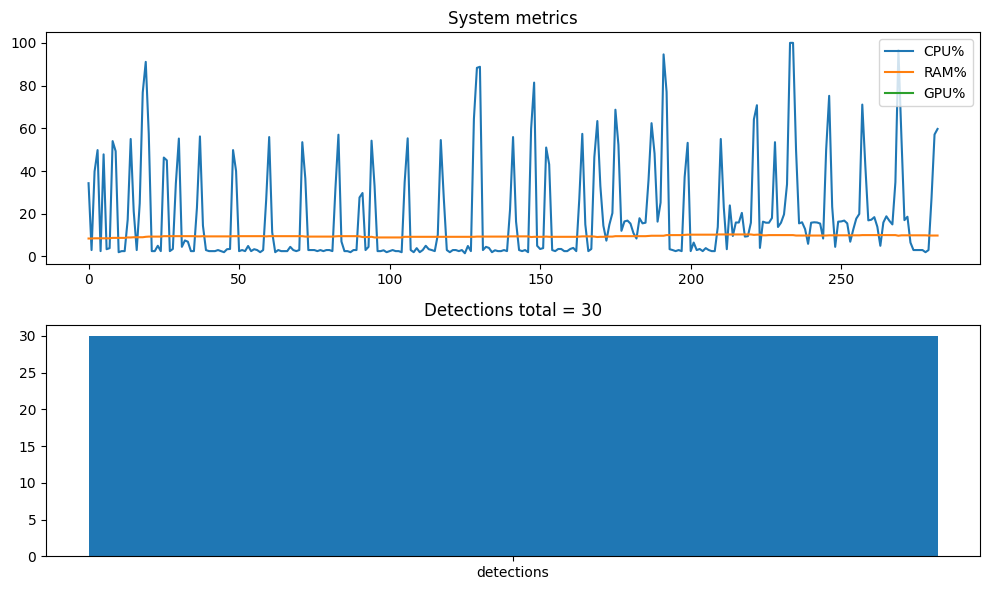

In [12]:
dashboard_refresh()
